# Choosing box size: alpha-gamma sweep

Map how solution density, liftability to DNS, and TW vs equilibrium existence vary with (alpha, gamma) or equivalently (Lx, Lz).


## 1. Setup

In [1]:
using LinearAlgebra, Statistics, Random, SparseArrays
using DataFrames, Plots
using Dates
using Serialization
using Base.Threads

using CloudAtlas
using ChannelflowWrapper
using DifferentialEquations

# Physical parameters
Re = 400.0

# Symmetry subgroup(s) for EQB search
sx, sy, sz, tx, tz = halfbox_symmetries()
H_eqb = [sx * sy * sz, sz * tx * tz]

# Symmetry subgroup for TW1 search
H_tw = [(sx * sy) * (tx * tz)]

# Truncation
J, K, L = 1, 2, 3

# Sweep grid in Lx, Lz (more interpretable)
Lx_vals = range(pi, 6 * pi; length=9)
Lz_vals = range(pi/2, 4 * pi; length=8)

# Convert to (alpha, gamma)
alpha_vals = 2 * pi ./ Lx_vals
gamma_vals = 2 * pi ./ Lz_vals

# ODE solver parameters
hookparams = SearchParams(ftol=1e-8, xtol=1e-12, Nnewton=30, Nhook=8, verbosity=0)

# Fuzzing / distinctness parameters
xnorm = 0.40
norm_threshold = 1e-2
distinct_tol = 1e-4

# Survival experiment parameters
survival_N_ic = 20
survival_E0 = 1e-2
survival_T_end = 200.0
survival_dt = 1.0
survival_E_thr_ratio = 1e-3

do_survival = true

# DNS lift settings (optional)
do_dns_lift_eqb = false
do_dns_lift_tw = false

base_dir = "notebooks/boxsize/boxsize_sweep_results"
mkpath(base_dir)

# EQB lift settings
symm_file_eqb = "notebooks/boxsize/sztx.asc"
reference_path_eqb = "./reference_field.nc"  # set to a valid DNS field
T_dns_eqb = 10.0

# TW1 lift settings
symm_file_tw = "notebooks/boxsize/sxytxz.asc"
reference_path_tw = "TW1-2pi1piRe200-40x49x40.nc"  # update if needed
T_dns_tw = 10.0


10.0

## 2. Define a standardized discovery protocol

This is a placeholder scaffold. Plug in your solver (Newton, GMRES, etc.) and
return a structured result with counts, solutions, and timings.


In [2]:
struct DiscoverResult
    n_converged::Int
    solutions::Vector{Any}
    representatives::Vector{Any}
    dns_attempts::Int
    dns_successes::Int
    timings::Dict{Symbol, Float64}
end

struct SolutionFingerprint
    cx::Float64
    cz::Float64
    nm::Float64
end

function is_distinct(new_fp::SolutionFingerprint, archive::Vector{SolutionFingerprint}; tol=1e-4)
    for fp in archive
        if isapprox(new_fp.cx, fp.cx, atol=tol) &&
           isapprox(new_fp.cz, fp.cz, atol=tol) &&
           isapprox(new_fp.nm, fp.nm, atol=tol)
            return false
        end
    end
    return true
end

# Distance in coefficient space: (x - y)' B (x - y)
function b_distance(x, y, B)
    dx = x - y
    dot(dx, B * dx)
end

function lift_eqb_to_dns(x, model, reference_field_converted, sol_dir; Re, symm_file, T)
    mkpath(sol_dir)
    guess_path = joinpath(sol_dir, "u_guess.nc")

    coeff2field(x, model.ijkl, reference_field_converted, guess_path)

    try
        findsoln(guess_path;
            R = Re, eqb = true,
            symms = abspath(symm_file),
            od = sol_dir, T = T
        )
        return true
    catch e
        println("findsoln failed: $e")
        return false
    end
end

function lift_tw_to_dns(x, cx, cz, model, reference_field_converted, sol_dir; Re, symm_file, T)
    mkpath(sol_dir)
    guess_path = joinpath(sol_dir, "u_guess.nc")
    sigma_file = joinpath(sol_dir, "sigma.asc")

    coeff2field(x, model.ijkl, reference_field_converted, guess_path)
    save_sigma(model, cx, cz, T, sigma_file)

    try
        findsoln(guess_path;
            R = Re, eqb = true,
            xrel = model.keep_cx, zrel = model.keep_cz,
            symms = abspath(symm_file),
            sigma = sigma_file, od = sol_dir, T = T
        )
        return true
    catch e
        println("findsoln failed: $e")
        return false
    end
end

function discover_eqb_solutions(; alpha, gamma, J, K, L, H, Re,
                                  Nguess=10_000, seed=0,
                                  xnorm=xnorm, norm_threshold=norm_threshold,
                                  distinct_tol=distinct_tol,
                                  hookparams=hookparams,
                                  do_dns_lift=do_dns_lift_eqb,
                                  base_dir=base_dir,
                                  reference_path=reference_path_eqb,
                                  symm_file=symm_file_eqb,
                                  T=T_dns_eqb)
    Random.seed!(seed)

    t0 = time()

    model = ODEModel(alpha, gamma, J, K, L, H)
    m = length(model)
    B = model.B

    f(x) = model.f(x, Re)
    Df(x) = model.Df(x, Re)

    io_lock = ReentrantLock()
    data_lock = ReentrantLock()

    solutions = Vector{Any}()
    representatives = Vector{Any}()

    dns_attempts = Atomic{Int}(0)
    dns_successes = Atomic{Int}(0)

    reference_field_converted = nothing
    if do_dns_lift
        mkpath(base_dir)
        if reference_path == "./reference_field.nc"
            lock(io_lock) do
                println("reference_path_eqb not set; skipping DNS lift")
            end
        else
            reference_field_converted = joinpath(base_dir, "reference_field_eqb_$(alpha)_$(gamma).nc")
            changegrid(reference_path, reference_field_converted; al=alpha, ga=gamma)
        end
    end

    function is_distinct_eqb(x)
        for r in representatives
            if b_distance(x, r[:x], B) < distinct_tol
                return false
            end
        end
        return true
    end

    @threads for i in 1:Nguess
        if i % 100 == 0
            println("Step $(i)")
        end
        
        x_guess = randn(m)
        x_guess = xnorm / norm(x_guess) * x_guess

        x_star, converged = hookstepsolve(f, Df, x_guess, hookparams)
        if !converged
            continue
        end
        # println("Found a convergent EQB solution!")

        solution_norm = norm(x_star)
        if solution_norm <= norm_threshold
            continue
        end

        residual = norm(f(x_star))
        sol = (x=x_star, norm=solution_norm, residual=residual)

        is_new = false
        lock(data_lock) do
            push!(solutions, sol)
            if is_distinct_eqb(x_star)
                push!(representatives, sol)
                is_new = true
            end
        end

        if is_new && do_dns_lift && reference_field_converted !== nothing
            timestamp = Dates.format(now(), "MM-DD-HHMMSS")
            sol_dir = joinpath(base_dir, "eqb_$(J)_$(K)_$(L)_id$(i)_$(timestamp)")

            atomic_add!(dns_attempts, 1)
            ok = lift_eqb_to_dns(x_star, model, reference_field_converted, sol_dir;
                                 Re=Re, symm_file=symm_file, T=T)
            if ok
                atomic_add!(dns_successes, 1)
            end
        end
    end

    timings = Dict{Symbol, Float64}(:elapsed => time() - t0)
    DiscoverResult(length(representatives), solutions, representatives,
                   dns_attempts[], dns_successes[], timings)
end

function discover_tw_solutions(; alpha, gamma, J, K, L, H, Re,
                                 Nguess=10_000, seed=0,
                                 xnorm=xnorm, norm_threshold=norm_threshold,
                                 hookparams=hookparams,
                                 do_dns_lift=do_dns_lift_tw,
                                 base_dir=base_dir,
                                 reference_path=reference_path_tw,
                                 symm_file=symm_file_tw,
                                 T=T_dns_tw)
    Random.seed!(seed)

    t0 = time()

    model = TWModel(alpha, gamma, J, K, L, H; normalize=false)
    m = length(model)

    io_lock = ReentrantLock()
    data_lock = ReentrantLock()

    solutions = Vector{Any}()
    representatives = Vector{Any}()
    solution_archive = Vector{SolutionFingerprint}()

    dns_attempts = Atomic{Int}(0)
    dns_successes = Atomic{Int}(0)

    reference_field_converted = nothing
    if do_dns_lift
        mkpath(base_dir)
        if reference_path == "TW1-2pi1piRe200-40x49x40.nc"
            lock(io_lock) do
                println("reference_path_tw not set; skipping DNS lift")
            end
        else
            reference_field_converted = joinpath(base_dir, "reference_field_tw_$(alpha)_$(gamma).nc")
            changegrid(reference_path, reference_field_converted; al=alpha, ga=gamma)
        end
    end

    @threads for i in 1:Nguess
        if i % 100 == 0
            println("Step $(i)")
        end
        x_guess = randn(m)
        x_guess = xnorm / norm(x_guess) * x_guess
        cx_guess = randn() * 0.1
        cz_guess = randn() * 0.1
        ξ_guess = [x_guess; cx_guess; cz_guess]

        f(ξ) = model.g(ξ, Re)
        Df(ξ) = model.Dg(ξ, Re)

        ξ_star, converged = hookstepsolve(f, Df, ξ_guess, hookparams)
        if !converged
            continue
        end
        # println("Found a convergent TW solution!")

        solution_norm = norm(ξ_star[1:m])
        if solution_norm <= norm_threshold
            continue
        end

        x_found, cx_found, cz_found = extract_components(ξ_star, model)
        new_fp = SolutionFingerprint(cx_found, cz_found, solution_norm)

        is_new = false
        lock(data_lock) do
            if is_distinct(new_fp, solution_archive)
                push!(solution_archive, new_fp)
                push!(representatives, (x=x_found, cx=cx_found, cz=cz_found, norm=solution_norm))
                is_new = true
            end
            push!(solutions, (x=x_found, cx=cx_found, cz=cz_found, norm=solution_norm))
        end

        if is_new && do_dns_lift && reference_field_converted !== nothing
            timestamp = Dates.format(now(), "MM-DD-HHMMSS")
            sol_dir = joinpath(base_dir, "tw_$(J)_$(K)_$(L)_id$(i)_$(timestamp)")

            atomic_add!(dns_attempts, 1)
            ok = lift_tw_to_dns(x_found, cx_found, cz_found, model, reference_field_converted, sol_dir;
                                Re=Re, symm_file=symm_file, T=T)
            if ok
                atomic_add!(dns_successes, 1)
            end
        end
    end

    timings = Dict{Symbol, Float64}(:elapsed => time() - t0)
    DiscoverResult(length(representatives), solutions, representatives,
                   dns_attempts[], dns_successes[], timings)
end

function survival_experiment(; alpha, gamma, J, K, L, H, Re,
                               N_ic=survival_N_ic, E0=survival_E0,
                               T_end=survival_T_end, save_dt=survival_dt,
                               E_thr_ratio=survival_E_thr_ratio,
                               seed=0)
    Random.seed!(seed)

    model = ODEModel(alpha, gamma, J, K, L, H)
    m = length(model)
    B = model.B

    E_thr = E0 * E_thr_ratio
    decay_times = Float64[]
    survivors = 0

    f!(dx, x, p, t) = (dx .= model.f(x, Re))

    for i in 1:N_ic
        x0 = randn(m)
        scale = sqrt((2 * E0) / dot(x0, B * x0))
        x0 .= scale .* x0

        prob = ODEProblem(f!, x0, (0.0, T_end))
        sol = solve(prob, Tsit5(); saveat=save_dt, abstol=1e-8, reltol=1e-6)

        energies = [0.5 * dot(u, B * u) for u in sol.u]
        t_decay = T_end
        for (t, E) in zip(sol.t, energies)
            if E < E_thr
                t_decay = t
                break
            end
        end

        if t_decay >= T_end
            survivors += 1
        end
        push!(decay_times, t_decay)
    end

    survival_fraction = survivors / N_ic
    median_decay_time = median(decay_times)
    return survival_fraction, median_decay_time
end

function discover_solutions(; alpha, gamma, J, K, L, H, Re,
                              Nguess=10_000, seed=0, mode=:eqb,
                              base_dir=base_dir)
    if mode == :eqb
        return discover_eqb_solutions(alpha=alpha, gamma=gamma, J=J, K=K, L=L, H=H, Re=Re,
                                      Nguess=Nguess, seed=seed, base_dir=base_dir)
    elseif mode == :tw
        return discover_tw_solutions(alpha=alpha, gamma=gamma, J=J, K=K, L=L, H=H, Re=Re,
                                     Nguess=Nguess, seed=seed, base_dir=base_dir)
    else
        error("unknown mode: $mode")
    end
end


discover_solutions (generic function with 1 method)

## 3. Clustering / uniqueness in coefficient space

Use the B inner-product metric to avoid counting duplicates.


In [3]:
function cluster_solutions(solutions, B; tol=1e-6)
    reps = Vector{Any}()
    for s in solutions
        x = s[:x]
        is_new = true
        for r in reps
            if b_distance(x, r[:x], B) < tol
                is_new = false
                break
            end
        end
        if is_new
            push!(reps, s)
        end
    end
    reps
end


cluster_solutions (generic function with 1 method)

## 4. Lift to DNS (optional)

Run DNS only on clustered representatives to keep cost down.


In [4]:
# DNS lift happens inside discover_eqb_solutions and discover_tw_solutions when enabled.


## 5. Sweep loop and collect metrics

For each (alpha, gamma) pair, discover equilibria/TWs, cluster them, and compute
rates per 10k guesses. Optionally lift selected reps to DNS.


In [5]:
results = DataFrame(
    Lx=Float64[], Lz=Float64[], alpha=Float64[], gamma=Float64[],
    n_eqb=Int[], n_tw=Int[],
    eqb_per_10k=Float64[], tw_per_10k=Float64[],
    eqb_dns_success_rate=Float64[], tw_dns_success_rate=Float64[],
    survival_fraction=Float64[], median_decay_time=Float64[],
)

Nguess = 10_000

for (i, Lx) in enumerate(Lx_vals)
    alpha = alpha_vals[i]
    for (j, Lz) in enumerate(Lz_vals)
        gamma = gamma_vals[j]

        eqb_base_dir = joinpath(base_dir, "eqb_Lx$(round(Lx, digits=3))_Lz$(round(Lz, digits=3))")
        tw_base_dir = joinpath(base_dir, "tw_Lx$(round(Lx, digits=3))_Lz$(round(Lz, digits=3))")

        eqb = discover_solutions(alpha=alpha, gamma=gamma, J=J, K=K, L=L, H=H_eqb, Re=Re,
                                 Nguess=Nguess, mode=:eqb, base_dir=eqb_base_dir)

        tw = discover_solutions(alpha=alpha, gamma=gamma, J=J, K=K, L=L, H=H_tw, Re=Re,
                                Nguess=Nguess, mode=:tw, base_dir=tw_base_dir)

        n_eqb = eqb.n_converged
        n_tw = tw.n_converged

        eqb_dns_rate = eqb.dns_attempts > 0 ? (eqb.dns_successes / eqb.dns_attempts) : NaN
        tw_dns_rate = tw.dns_attempts > 0 ? (tw.dns_successes / tw.dns_attempts) : NaN

        if do_survival
            surv_frac, med_decay = survival_experiment(alpha=alpha, gamma=gamma, J=J, K=K, L=L,
                                                       H=H_eqb, Re=Re)
        else
            surv_frac, med_decay = NaN, NaN
        end

        push!(results, (
            Lx, Lz, alpha, gamma,
            n_eqb, n_tw,
            10_000 * n_eqb / Nguess,
            10_000 * n_tw / Nguess,
            eqb_dns_rate, tw_dns_rate,
            surv_frac, med_decay,
        ))

        serialize(joinpath(base_dir, "eqb_results_Lx$(round(Lx, digits=3))_Lz$(round(Lz, digits=3)).jls"), eqb)
        serialize(joinpath(base_dir, "tw_results_Lx$(round(Lx, digits=3))_Lz$(round(Lz, digits=3)).jls"), tw)
    end
end

serialize(joinpath(base_dir, "boxsize_sweep_results.jls"), results)

results[1:10, :]


J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
Step 100
Step 200
Step 300
Step 400
Step 500
Step 600
Step 700
Step 800
Step 900
Step 1000
Step 1100
Step 1200
Step 1300
Step 1400
Step 1500
Step 1600
Step 1700
Step 1800
Step 1900
Step 2000
Step 2100
Step 2200
Step 2300
Step 2400
Step 2500
Step 2600
Step 2700
Step 2800
Step 2900
Step 3000
Step 3100
Step 3200
Step 3300
Step 3400
Step 3500
Step 3600
Step 3700
Step 3800
Step 3900
Step 4000
Step 4100
Step 4200
Step 4300
Step 4400
Step 4500
Step 4600
Step 4700
Step 4800
Step 4900
Step 5000
Step 5100
Step 5200
Step 5300
Step 5400
Step 5500
Step 5600
Step 5700
Step 5800
Step 5900
Step 6000
Step 6100
Step 6200
Step 6300
Step 6400
Step 6500
Step 6600
Step 6700
Step 6800
Step 6900
Step 7000
Step 7100
Step 7200
Step 7300
Step 7400
Step 7500
Step 7600
Step 7700
Step 7800
Step 7900
Step 8000
Step 8100
Step 8200
Step 

Row,Lx,Lz,alpha,gamma,n_eqb,n_tw,eqb_per_10k,tw_per_10k,eqb_dns_success_rate,tw_dns_success_rate,survival_fraction,median_decay_time
,Float64,Float64,Float64,Float64,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64
1,3.14159,1.5708,2.0,4.0,4,11,4.0,11.0,NaN,NaN,0.2,154.5
2,3.14159,3.14159,2.0,2.0,14,11,14.0,11.0,NaN,NaN,1.0,200.0
3,3.14159,4.71239,2.0,1.33333,24,22,24.0,22.0,NaN,NaN,1.0,200.0
4,3.14159,6.28319,2.0,1.0,28,21,28.0,21.0,NaN,NaN,1.0,200.0
5,3.14159,7.85398,2.0,0.8,12,11,12.0,11.0,NaN,NaN,1.0,200.0
6,3.14159,9.42478,2.0,0.666667,12,5,12.0,5.0,NaN,NaN,1.0,200.0
7,3.14159,10.9956,2.0,0.571429,12,3,12.0,3.0,NaN,NaN,1.0,200.0
8,3.14159,12.5664,2.0,0.5,14,4,14.0,4.0,NaN,NaN,0.9,200.0
9,5.10509,1.5708,1.23077,4.0,0,3,0.0,3.0,NaN,NaN,0.15,163.5


## 6. Heatmaps / phase diagrams

Make density maps and liftability overlays for the sweep results.


In [6]:
function heatmap_from_results(results, field; title="", xlabel="Lz", ylabel="Lx")
    Lx = sort(unique(results.Lx))
    Lz = sort(unique(results.Lz))
    grid = fill(NaN, length(Lx), length(Lz))
    for row in eachrow(results)
        ix = findfirst(==(row.Lx), Lx)
        iz = findfirst(==(row.Lz), Lz)
        grid[ix, iz] = row[field]
    end
    plt = heatmap(Lz, Lx, grid; xlabel=xlabel, ylabel=ylabel, title=title)
    return plt, Lx, Lz, grid
end

plot_title = "Re=$(Re), J=$(J), K=$(K), L=$(L)"

# A1: survival fraction heatmap
plt1, Lx_grid, Lz_grid, Sgrid = heatmap_from_results(
    results, :survival_fraction,
    title="Survival fraction (" * plot_title * ")",
    xlabel="Lz", ylabel="Lx",
)
contour!(Lz_grid, Lx_grid, Sgrid; levels=[0.1, 0.5, 0.9], color=:white, linewidth=1)

# A2: median decay time heatmap
plt2, Lx_grid2, Lz_grid2, Tgrid = heatmap_from_results(
    results, :median_decay_time,
    title="Median decay time (" * plot_title * ")",
    xlabel="Lz", ylabel="Lx",
)


(Plot{Plots.GRBackend() n=1}, [3.141592653589793, 5.105088062083414, 7.0685834705770345, 9.032078879070655, 10.995574287564276, 12.959069696057897, 14.922565104551516, 16.886060513045138, 18.84955592153876], [1.5707963267948966, 3.141592653589793, 4.71238898038469, 6.283185307179586, 7.853981633974483, 9.42477796076938, 10.995574287564276, 12.566370614359172], [154.5 200.0 … 200.0 200.0; 163.5 200.0 … 200.0 200.0; … ; 148.0 200.0 … 200.0 200.0; 151.5 200.0 … 200.0 200.0])

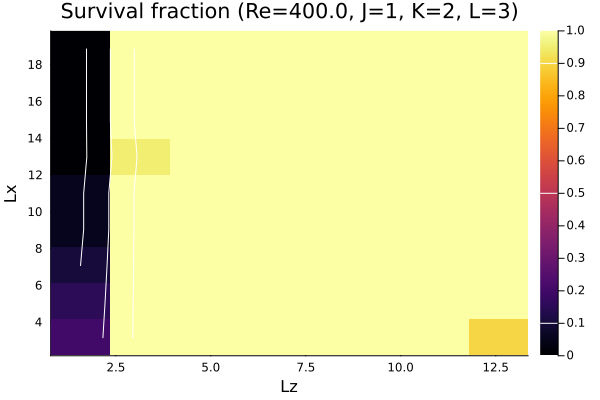

In [13]:
display(plt1)

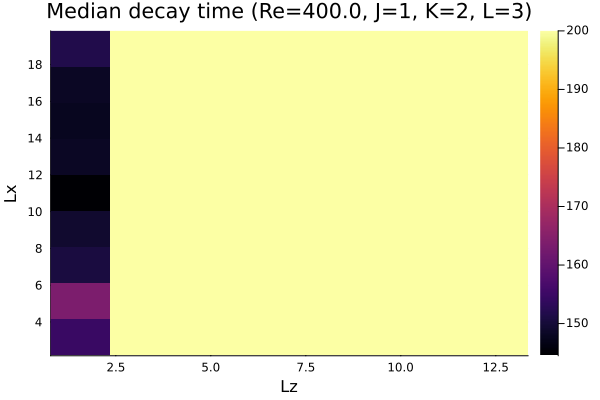

In [14]:
display(plt2)

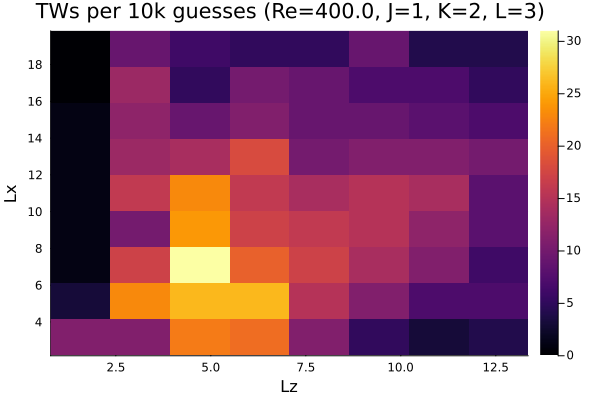

In [15]:
plt_tw, _, _, _ = heatmap_from_results(
    results, :tw_per_10k,
    title="TWs per 10k guesses (" * plot_title * ")",
    xlabel="Lz", ylabel="Lx",
)
display(plt_tw)

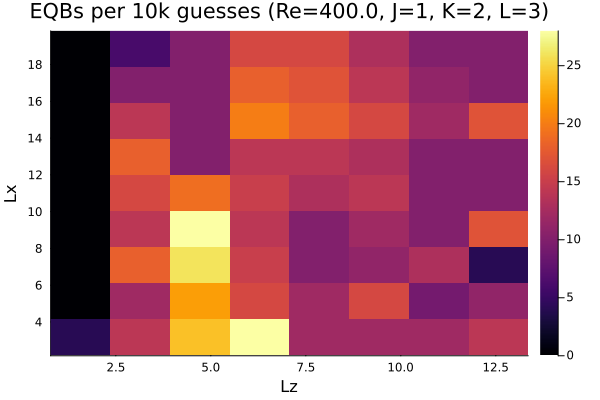

In [17]:
plt_eqb, _, _, _ = heatmap_from_results(
    results, :eqb_per_10k,
    title="EQBs per 10k guesses (" * plot_title * ")",
    xlabel="Lz", ylabel="Lx",
)
display(plt_eqb)

In [8]:
plt_dns, _, _, _ = heatmap_from_results(
    results, :tw_dns_success_rate,
    title="TW DNS lift success rate (" * plot_title * ")",
    xlabel="Lz", ylabel="Lx",
)


(Plot{Plots.GRBackend() n=1}, [3.141592653589793, 5.105088062083414, 7.0685834705770345, 9.032078879070655, 10.995574287564276, 12.959069696057897, 14.922565104551516, 16.886060513045138, 18.84955592153876], [1.5707963267948966, 3.141592653589793, 4.71238898038469, 6.283185307179586, 7.853981633974483, 9.42477796076938, 10.995574287564276, 12.566370614359172], [NaN NaN … NaN NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN NaN; NaN NaN … NaN NaN])

## 7. Minimum box sustaining turbulence proxy

Two options:

- ODE chaos proxy: long integrations from random ICs and detect chaotic behavior.
- ECS richness proxy: count distinct EQ/TW across the grid and look for onset.


In [9]:
# Placeholder: ODE chaos proxy
function chaos_proxy(alpha, gamma)
    # TODO: integrate and estimate Lyapunov or broadband spectrum
    return NaN
end


chaos_proxy (generic function with 1 method)

In [10]:
# Example: build a proxy grid
# chaos_grid = [chaos_proxy(alpha_vals[i], gamma_vals[j]) for i in eachindex(alpha_vals), j in eachindex(gamma_vals)]
# heatmap(Lz_vals, Lx_vals, chaos_grid, xlabel="Lz", ylabel="Lx", title="Chaos proxy")


## 8. Identify promising boxes

Filter for boxes with high ODE density and high DNS success (if available).


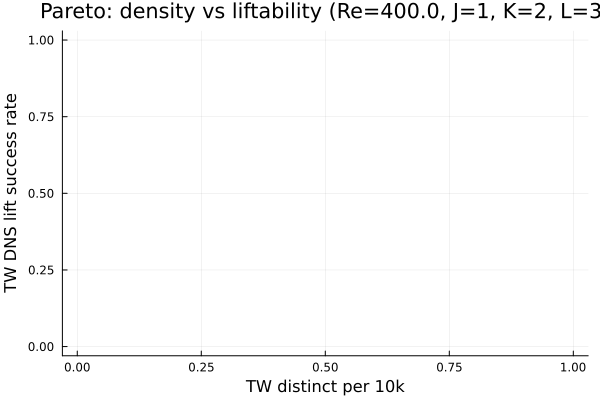

In [11]:
# C1: Pareto scatter for box selection
valid = filter(row -> isfinite(row.tw_per_10k) && isfinite(row.tw_dns_success_rate) && isfinite(row.survival_fraction), results)

score(row) = row.survival_fraction * row.tw_per_10k * row.tw_dns_success_rate
sorted = sort(valid, :tw_per_10k, rev=true)

plt_pareto = scatter(
    valid.tw_per_10k,
    valid.tw_dns_success_rate;
    markersize=10 .* valid.survival_fraction,
    xlabel="TW distinct per 10k",
    ylabel="TW DNS lift success rate",
    title="Pareto: density vs liftability (" * plot_title * ")",
    label=false,
)

# Annotate top 5 by score
if nrow(valid) > 0
    top = sort(valid, :tw_per_10k, rev=true)
    top = sort(top, :tw_dns_success_rate, rev=true)
    ranked = sort(valid, by=score, rev=true)
    for row in eachrow(ranked[1:min(5, nrow(ranked)), :])
        annotate!(row.tw_per_10k, row.tw_dns_success_rate,
                  text("Lx=$(round(row.Lx, digits=2)), Lz=$(round(row.Lz, digits=2))", :left, 8))
    end
end

plt_pareto
